# QuanAllo — QuanAnt Machines

The **QuanAnt** machine is the flagship algorithm of this package. It's an ant colony of perturbed quantum walkers that **communicate via a shared (or per-species) pheromone field**.

Each "ant" is a single quantum-method instance with randomly perturbed hyperparameters. At each iteration:

1. Every ant runs once with the current pheromone field as a soft bias.
2. The top-k residues of each ant deposit 1 unit of pheromone.
3. The field evaporates by `(1 - evap_rate)` and the new deposits are added.

Over iterations, residues that are *consistently* ranked high across the colony accumulate strong pheromone — yielding a robust consensus prediction.

This notebook covers:

1. **Single-species colonies** — a colony of one method type.
2. **Heterogeneous colonies** — multiple species sharing a pheromone field.
3. **Adaptive QuanAnt** — APO-to-HOLO transfer learning with online weight updates.

## 0. Setup — load apo + holo

In [12]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from quanallo import ProteinGraph, AllostericPredictor
from quanallo.quanant import QuanAntColony, AdaptiveQuanAnt

DATA = "input_Myosin"  # adjust to your path

def _build_weighted(edges_df, N):
    A = np.zeros((N, N))
    for _, r in edges_df.iterrows():
        i, j = int(r['i']), int(r['j']); w = float(r['weight'])
        A[i, j] = w; A[j, i] = w
    return A

def load_graph(side):
    prefix = "apo" if side == "apo" else "holo"
    nodes = pd.read_csv(f"{DATA}/{prefix}_nodes.csv")
    edges = pd.read_csv(f"{DATA}/{prefix}_edges.csv")
    A_bin = np.load(f"{DATA}/{prefix}_adjacency.npy").astype(float)
    A_w   = _build_weighted(edges, len(nodes))
    key = nodes.set_index(['chain','resnum'])['idx']
    def _to_idx(df):
        return np.array([int(key.loc[(r.chain, int(r.resnum))])
                          for _, r in df.iterrows()
                          if (r.chain, int(r.resnum)) in key.index])
    active_csv = "apo_active_site.csv" if side == "apo" else "apo_active_site.csv"
    gt_csv = "holo_ground_truth.csv" if side == "apo" else "holo_ground_truth.csv"
    return ProteinGraph(nodes=nodes, adjacency_binary=A_bin, adjacency_weighted=A_w,
                        active_idx=_to_idx(pd.read_csv(f"{DATA}/{active_csv}")),
                        ground_truth_idx=_to_idx(pd.read_csv(f"{DATA}/{gt_csv}")),
                        name=f"KRAS_G12C_{side.upper()}")

apo, holo = load_graph("apo"), load_graph("holo")

## 1. Single-species QuanAnt colony

A colony of `dqaw_lifetime` ants — each with slightly perturbed hyperparameters — communicating via a shared pheromone field. With enough ants (~30) and iterations (~8), the ensemble averages out hyperparameter sensitivity.

In [13]:
colony = QuanAntColony(
    species=["dqaw_lifetime"],
    ants_per_species=10,           # 10 perturbed ants
    n_iter=5,                      # 5 pheromone updates
    evap_rate=0.30,
    deposit_topk=5,
    pher_strength=2.0,             # how strongly pheromone biases ants
    parallel=True,                 # uses thread pool
    verbose=True,
)
result = colony.run(holo)
print()
print("Final top-5:", [holo.residue_at(i)['resnum'] for i in
                        np.argsort(result.final_score)[::-1][:5]])

  iter 1/5  pher_max=1.035
  iter 2/5  pher_max=1.550
  iter 3/5  pher_max=1.787
  iter 4/5  pher_max=1.661
  iter 5/5  pher_max=1.783

Final top-5: [121, 118, 130, 122, 363]


## 2. Heterogeneous (multi-species) QuanAnt

Five species share a single pheromone field. Each one's deposits influence what *every* species does next — so methods that find similar residues amplify each other (consensus), while outlier species get drowned out by the majority.

**Three aggregation modes** are supported:

| Mode                     | Pheromone topology                              | When to use                                  |
|--------------------------|-------------------------------------------------|----------------------------------------------|
| `shared_pheromone`       | One field, uniform deposits                     | All species roughly equally trustworthy      |
| `weighted_consensus`     | One field, deposits scaled by `species_weights` | You have prior reliability info              |
| `multi_pheromone`        | Each species has its **own** field              | Species disagree → don't pollute each other  |

In [14]:
# Heterogeneous, shared pheromone (no priors)
colony = QuanAntColony(
    species=['qsvd', 'dqaw_timeavg', 'dqaw_lifetime', 'qpagerank', 'heatkernel'],
    ants_per_species=4,
    n_iter=5,
    aggregation='shared_pheromone',
    parallel=True,
)
result = colony.run(holo)
print(f"Shared-pheromone consensus HOLO top-5:")
for i in np.argsort(result.final_score)[::-1][:5]:
    print(f"  {holo.residue_at(i)['chain']}{holo.residue_at(i)['resnum']}  "
          f"score={result.final_score[i]:.3f}")

Shared-pheromone consensus HOLO top-5:
  A226  score=2.782
  A228  score=1.855
  A227  score=1.855
  A225  score=1.542
  A224  score=1.471


## 3. Multi-pheromone — each species gets its own field

Useful when species disagree — each one converges to its own consensus without being polluted by the others.

In [15]:
colony = QuanAntColony(
    species=['qsvd', 'dqaw_lifetime', 'qpagerank', 'heatkernel'],
    ants_per_species=4,
    n_iter=5,
    aggregation='multi_pheromone',
    parallel=True,
)
result = colony.run(holo)
# per_species_score now holds each species' own converged pheromone
for sp, score in result.per_species_score.items():
    top = np.argsort(score)[::-1][:3]
    print(f"  {sp:<15} top-3 resnums = "
          f"{[holo.residue_at(i)['resnum'] for i in top]}")

  qsvd            top-3 resnums = [226, 307, 222]
  dqaw_lifetime   top-3 resnums = [121, 122, 51]
  qpagerank       top-3 resnums = [228, 249, 227]
  heatkernel      top-3 resnums = [188, 187, 190]


## 4. Adaptive QuanAnt — APO→HOLO transfer learning

The **flagship** algorithm. Two stages:

### Stage 1 — `fit(apo_graph)`

Each species runs independently on APO (with its own pheromone field). We measure each species' `weighted_top5` against APO ground truth. These become per-species **reliability weights** via softmax with floor.

### Stage 2 — `predict(holo_graph)`

Run a weighted-consensus colony on HOLO, starting from the APO-learned weights. Each iteration, weights are updated by a **Jaccard-agreement** signal between species' top-k:

$$
w_{t+1} = \text{momentum} \cdot w_{\rm APO} + (1 - \text{momentum}) \cdot w_{\rm Jaccard, t}
$$

Then softmax with floor preserves diversity. This combines APO prior knowledge with online correction when species disagree on HOLO.

In [16]:
adaptive = AdaptiveQuanAnt(
    species=['qsvd', 'dqaw_timeavg', 'dqaw_lifetime', 'qpagerank', 'heatkernel'],
    ants_per_species=4,
    n_iter=5,
    softmax_temperature=1.0,        # higher = flatter, more robust to species swap
    weight_floor=0.10,              # min per-species weight
    adaptive_momentum=0.40,         # lower = more responsive to HOLO online updates
    parallel=True,
    verbose=True,
)
adaptive.fit(apo)
print("\nAPO-learned species weights:")
for sp, w in adaptive.apo_weights.items():
    print(f"  {sp:<16} weight={w:.3f}  (raw score={adaptive._apo_species_scores[sp]:.3f})")

  iter 1/5  pher_max=1.035
  iter 2/5  pher_max=1.724
  iter 3/5  pher_max=2.207
  iter 4/5  pher_max=2.545
  iter 5/5  pher_max=2.782

[AdaptiveQuanAnt] APO-learned species weights:
   qsvd             0.110  (raw=0.105)
   dqaw_timeavg     0.152  (raw=0.430)
   dqaw_lifetime    0.127  (raw=0.250)
   qpagerank        0.344  (raw=1.250)
   heatkernel       0.268  (raw=1.000)

APO-learned species weights:
  qsvd             weight=0.110  (raw score=0.105)
  dqaw_timeavg     weight=0.152  (raw score=0.430)
  dqaw_lifetime    weight=0.127  (raw score=0.250)
  qpagerank        weight=0.344  (raw score=1.250)
  heatkernel       weight=0.268  (raw score=1.000)


In [17]:
result = adaptive.predict(holo)
top_5 = np.argsort(result.final_score)[::-1][:5]
print("\nFinal HOLO top-5:")
for i in top_5:
    info = holo.residue_at(i)
    print(f"  {info['chain']}{info['resnum']}  pher={result.final_score[i]:.3f}")

  iter 1/5  weights=qsv=0.19 dqa=0.19 dqa=0.19 qpa=0.22 hea=0.21
  iter 2/5  weights=qsv=0.19 dqa=0.19 dqa=0.19 qpa=0.21 hea=0.21
  iter 3/5  weights=qsv=0.19 dqa=0.20 dqa=0.19 qpa=0.21 hea=0.21
  iter 4/5  weights=qsv=0.18 dqa=0.20 dqa=0.18 qpa=0.22 hea=0.22
  iter 5/5  weights=qsv=0.18 dqa=0.19 dqa=0.19 qpa=0.22 hea=0.22

Final HOLO top-5:
  A226  pher=2.772
  A228  pher=1.953
  A227  pher=1.914
  A225  pher=1.508
  A224  pher=1.466


## 5. Visualize the weight trajectory

The Jaccard-agreement online updates push species weights AWAY from their APO prior if a species disagrees with the others on HOLO. This is visible as drift in the weight history.

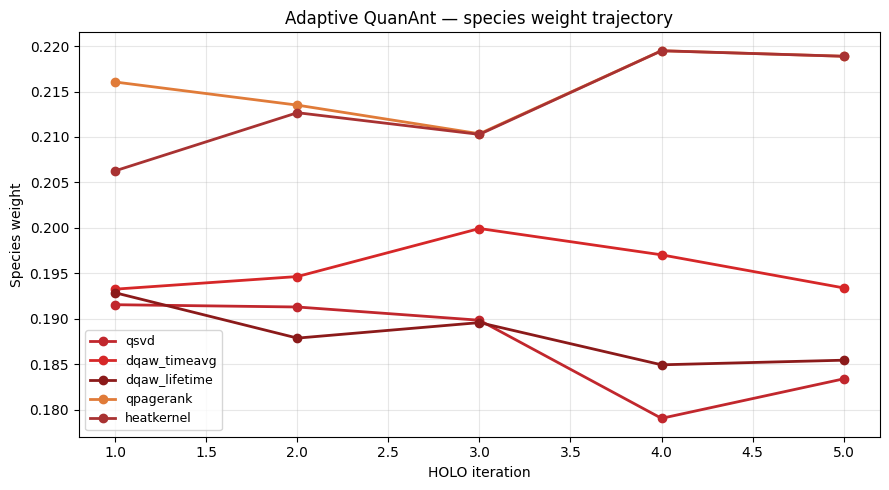

In [18]:
hist = result.species_weights_history
species = list(hist[0].keys())
iters = list(range(1, len(hist) + 1))

fig, ax = plt.subplots(figsize=(9, 5))
SPECIES_COLORS = {
    "qsvd":          "#c1272d",
    "dqaw_timeavg":  "#d62728",
    "dqaw_lifetime": "#8b1a1a",
    "qpagerank":     "#e07b39",
    "heatkernel":    "#a83232",
}
for sp in species:
    ax.plot(iters, [h[sp] for h in hist], "o-",
            color=SPECIES_COLORS.get(sp, "#888"), label=sp, linewidth=2)
ax.set_xlabel("HOLO iteration"); ax.set_ylabel("Species weight")
ax.set_title("Adaptive QuanAnt — species weight trajectory")
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc="best")
plt.tight_layout(); plt.show()

## 6. Compare all QuanAnt modes on HOLO

In [19]:
from quanallo import evaluate

def score(pher_or_score, label):
    ev = evaluate(pher_or_score, holo.adjacency_weighted, holo.ground_truth_idx,
                  holo.active_idx, holo.N, surface_mask=holo.surface_mask)
    print(f"  {label:<40} weighted_top5 = {ev['weighted_top5']:.3f}")

# Single best single-species (baseline)
r0 = AllostericPredictor(method='dqaw_lifetime').predict(holo)
print("Single-species baselines:")
score(r0.scores, "dqaw_lifetime (single)")

# Uniform consensus
colony = QuanAntColony(
    species=['qsvd', 'dqaw_timeavg', 'dqaw_lifetime', 'qpagerank', 'heatkernel'],
    ants_per_species=4, n_iter=5, aggregation='shared_pheromone', parallel=True)
r1 = colony.run(holo)
print("\nQuanAnt modes:")
score(r1.final_score, "Uniform consensus")

# Multi-pheromone (independent fields)
colony = QuanAntColony(
    species=['qsvd', 'dqaw_timeavg', 'dqaw_lifetime', 'qpagerank', 'heatkernel'],
    ants_per_species=4, n_iter=5, aggregation='multi_pheromone', parallel=True)
r2 = colony.run(holo)
score(r2.final_score, "Multi-pheromone")

# Adaptive
adaptive = AdaptiveQuanAnt(
    species=['qsvd', 'dqaw_timeavg', 'dqaw_lifetime', 'qpagerank', 'heatkernel'],
    ants_per_species=4, n_iter=5, parallel=True, verbose=False)
adaptive.fit(apo)
r3 = adaptive.predict(holo)
score(r3.final_score, "Adaptive (APO prior + online Jaccard)")

Single-species baselines:
  dqaw_lifetime (single)                   weighted_top5 = 0.531

QuanAnt modes:
  Uniform consensus                        weighted_top5 = 0.375
  Multi-pheromone                          weighted_top5 = 0.812
  Adaptive (APO prior + online Jaccard)    weighted_top5 = 0.375


## 8. Customizing & extending

To add a custom ant species:

```python
from quanallo.methods.base import AllosteryMethod
from quanallo.methods import METHOD_REGISTRY

class MyCustomMethod(AllosteryMethod):
    name: str = "my_custom"
    kind: str = "quantum"
    requires_active_site: bool = True

    def compute(self, graph):
        # ... your scoring logic ...
        return scores
    
    def compute_with_pheromone(self, graph, pheromone, *, pher_strength=1.0):
        # ... pheromone-aware variant ...
        return scores

METHOD_REGISTRY["my_custom"] = MyCustomMethod

# Now use in QuanAntColony or AllostericPredictor:
colony = QuanAntColony(species=["my_custom", "dqaw_lifetime"], ...)
```